Lezione 3 - My First Neural Network



*   Tensorflow and Keras
*   My First Neural Network
*   Esercizio con MLPClassifier di Scikit Learn
*   Introduzione al Transfer Learning

#Tensorflow


*   Nata come proggetto interno a Google (DistBelief), sviluppato da Google Brain nel 2011.
*   Codice rilasciato **open source nel 2015** con licenza Apache License 2.0.
*   **Keras** diventa interfaccia principale dal 2019 con **TensorFlow 2.0**
*   Il suo principale concorrente è Pytorch, creato da Facebook.

##Tensorflow in pratica

Nasce come framework per svolgere calcolo differenziale sui tensori.
Simile a numpy quindi però ha delle features in piu quali:

Riesce ad esegure anche su GPUs e TPUs.
Fa calcolo differenziale e quindi può computare direttamente qualsiasi equazione differenziabile di tensori.
La computazione può essere distribuita verso un grande numero di dispositivi o su una singola macchina o un grande numero di macchine ( potenzialmente con molti devices in ognuno)


E quindi Oggi tensorflow è diventata una end-to-end machine learning platform:

*   Metodi per preparare e caricare i dati.
*   Metodi per costruire modelli di ML.
*   Metodi per il deploy di ML
*   Metodi per mettere in produzione un modello di ML.



##TF strenghts


1.   Efficiently executing low-level tensor operations on CPU, GPU, or TPU.

2.   Computing the gradient of arbitrary differentiable expressions.

3.   Scaling computation to many devices, such as clusters of hundreds of GPUs.

4.   Exporting programs ("graphs") to external runtimes such as servers, browsers, mobile and embedded devices.


#Keras
Keras consente di costruire, addestrare e valutare reti neurali in modo efficiente e flessibile tramite un interfaccia di alto livello molto flessibile e facile da usare.

E' la api di default per TensorFlow, questo vuol dire che quando una rete neurale in keras, stiamo creando un modello di tensorflow.

> [Keras Ecosystem](https://keras.io/getting_started/ecosystem/)


##Create a Keras model


**Functional API**

In [ ]:
from keras.layers import Input, Dense
from keras.models import Model

def build_neural_network():
  in_layer = Input(shape=(4,), name="Input_Layer")
  x = Dense(units=128, activation='relu', name="Hidden_Layer_1")(in_layer)
  x = Dense(units=64, activation='relu', name="Hidden_Layer_2")(x)
  x = Dense(units=32, activation='relu', name="Hidden_Layer_3")(x)
  out_layer = Dense(units=10, activation='softmax',name="Output_Layer")(x)
  model = Model(inputs=in_layer, outputs=out_layer, name="MyFirstNeuralNetwork")
  return model

model = build_neural_network()

In [ ]:
model.summary()

Model: "MyFirstNeuralNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)             │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_1 (Dense)               │ (None, 128)                 │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_2 (Dense)               │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_3 (Dense)               │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,306 (44.16 KB)

 Trainable params: 11,306 (44.16 KB)

 Non-trainable params: 0 (0.00 B)

**Class Inerithance mode**

In [ ]:
import tensorflow as tf
from tensorflow import keras

class MyNeuralNetwork(keras.Model):
    def __init__(self):
        super(MyNeuralNetwork, self).__init__()
        self.dense1 = keras.layers.Dense(64, activation='relu', name="Dense1")
        self.dense2 = keras.layers.Dense(32, activation='relu', name="Dense2")
        self.dense3 = keras.layers.Dense(32, activation='relu', name="Dense3")
        self.dense4 = keras.layers.Dense(10, activation='softmax')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return x

model = MyNeuralNetwork()

**Sequantial mode**

In [ ]:
model = keras.Sequential(
    [
        keras.layers.Dense(2, activation="relu", name="layer1"),
        keras.layers.Dense(3, activation="relu", name="layer2"),
        keras.layers.Dense(4, name="layer3"),
    ]
)

##Layers

A single perceptron is made of:

![PERCEPTRON](https://drive.google.com/uc?id=1aCVcbcOYQCzyqRdftlclmqfoUXtOsu6M )

**L'algoritmo di backpropagation in un nustshell:**

*   Dati gli input calcola tutti gli output pesati e le attivazioni per ogni layer.
*   Calcola l'errore per l'ultimo layer usando la funzione di costo.
*   Propaga l'informazione all'indietro calcolando layer per layer il gradiente dell'errore rispetto ai pesi e ai bias.
*   Usa un algorimto di ottimizzazione come il gradient descent per aggiornare bias e pesi dal gradiente calcolato.


[TensorFlowPlayground](https://playground.tensorflow.org/#activation=sigmoid&regularization=L2&batchSize=11&dataset=spiral&regDataset=reg-plane&learningRate=0.001&regularizationRate=0&noise=50&networkShape=2,1&seed=0.16959&showTestData=true&discretize=true&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=true&ySquared=true&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)


Un esempio di Fully connected layer di keras.

*   Units.
*   Kernel e Bias.
*   Activation Function.

Quindi vediamo come sono organizzati e come possiamo usarli

In [ ]:
import tensorflow as tf
from keras.layers import Dense
from keras.regularizers import l1, l2, l1_l2
from keras.constraints import MinMaxNorm, NonNeg


layer = Dense(
    units=32,
    activation="relu",
    use_bias=True,

    #Inizializzazione dei pesi
    kernel_initializer=tf.keras.initializers.Ones(),
    bias_initializer=tf.keras.initializers.Zeros(),

    #Regolarizzatori
    kernel_regularizer=l1(l1=0.01), #Regolarizzazione Lasso, l1 * reduce_sum(abs(x))
    bias_regularizer=l2(l2=0.01),   #Regolarizzazione Ridge, l2 * reduce_sum(square(x))
    activity_regularizer=l1_l2(l1=0.01, l2=0.01), #penalty = l1 * reduce_sum(abs(x)) + l2*reduce_sum(square(x))

    #Vincoli
    kernel_constraint=MinMaxNorm(min_value=0.0, max_value=1.0),
    bias_constraint=NonNeg()
)



*   Gli initializer determinano come vengono inizializzati i pesi della rete influenzando la convergenza dell'addestramento.

*   I regularizer in Keras servono per controllare l'overfitting nei modelli
neurali,ad esempio aggiungendo una penalità ai pesi della rete durante l'addestramento indirettamente si modifica l'output rendendolo piu generale.

*    I constraints su intervalli, possono migliorare la stabilità del modello.

### Overfitting
L'overfitting in deep learning avviene quando un modello addestrato ha una prestazione eccellente ai dati di addestramento, al punto da perdere la sua capacità di generalizzazione su nuovi dati, dove invece si riscontra una prestazione significativamente peggiore.

Cause possibili di overfitting:

- Modello troppo intelligente, riduci la sua complessità.
- Scarso volume di dati, aumentali.
- Scarsa qualità nei dati: rumore o errori possono confondere il modello.

L'obiettivo è trovare un equilibrio tra l'adattamento ai dati di addestramento e la capacità di generalizzazione su nuovi dati.

##Training

Compilare il modello prima di chiamare il fit

In [ ]:
### Training Hyperparamenters
epochs_num=100
batch_size=32
lr = 0.0001
opt = ...
loss_fun = ...
metrics_list = [..., ..., ...]

def create_model():
  # return build_neural_network()
  return MyNeuralNetwork()

#model = create_model()
#model.compile( loss=loss_fun, optimizer=opt, metrics=metrics_list )
#model.fit( x_train, y_train, epochs=epochs_num, batch_size=batch_size, validation_data=(x_valid,y_valid) )

Il metodo "compile" richiede almeno due componenti essenziali senza i quali il fit non può funzionare:

*   Loss Function: La funzione serve a comparare i valori target con l'output del modello e quantifica l'errore che the optimizer tenta di minimizzare.

*   Optimizer: componente che determina le regole per cui fare l'update dei pesi del modello durante il training.

Il metodo compile inoltre può prendere altri parametri opzionali come le metriche che forniscono un monitoring delle performance del modello durante il training.

**Optimizers**..https://www.tensorflow.org/api_docs/python/tf/keras/optimizers

Questo processo di aggiornamento dei pesi può essere basato su varie tecniche di ottimizzazione:

- SGD = discesa del gradiente stocastica.
- Adam= Adaptive Moment Estimation.
- RMSProp= root mean square propagation.
- ...

Keras mette a disposizione le implementazioni degli algoritmi degli optimizers.

In [ ]:
from keras.optimizers import SGD, Adam, AdamW, RMSprop,schedules

#possiamo definire l'algorimto usando il nome
optimizer="adam"
optimizer="sgd"
optimizer="rmsp"

#keras implementa gli algo di opt, ognuno ha i suoi iperparamentri.
sgd = SGD(learning_rate=0.01)
adam = Adam(learning_rate=0.01)
adamw = AdamW(learning_rate=0.01)
rmsprop = RMSprop(learning_rate=0.001)

#keras implementa diversi algoritmi di learning rate scheduling:
lr_schedule_exp = schedules.ExponentialDecay(initial_learning_rate=1e-2, decay_steps=10000, decay_rate=0.9)
lr_schedule_pol = schedules.PolynomialDecay(initial_learning_rate=1e-2,decay_steps=10000,end_learning_rate=0.0001)
lr_schedule_cos = schedules.CosineDecay(initial_learning_rate=1e-2, decay_steps=10000, alpha=0.0)

optimizer = AdamW( learning_rate=lr_schedule_cos )

**Loss Functions**...
- https://keras.io/api/losses/



In [ ]:
from keras.losses import MeanSquaredError,MeanAbsoluteError,BinaryCrossentropy,KLDivergence,Huber,Loss

# Dati di esempio
y_true = tf.constant([0.0, 1.0, 1.0, 0.0])
y_pred = tf.constant([0.1, 0.9, 0.8, 0.2])

class CustomLoss(Loss):
    def __init__(self, name="custom_loss"):
        super(CustomLoss, self).__init__(name=name)
    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred))


def custom_loss_fun(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))


#Regressions
mse = MeanSquaredError()
mse_loss = mse(y_true, y_pred)


mae = MeanAbsoluteError()
mae_loss = mae(y_true, y_pred)

#Comportamento quadratico per piccoli errori, lineare per grandi errori
huber= Huber()
huber_loss = huber(y_true, y_pred)


#Probability Based
kl = KLDivergence()
kl_loss = kl(y_true, y_pred)


costum = CustomLoss()
custom_loss_function = custom_loss_fun(y_true, y_pred)
class_loss = costum(y_true, y_pred)


print("Mean Squared Error:", mse_loss)
print("Mean Absolute Error:", mae_loss)
print("KL Divergence:", kl_loss)
print("Huber Loss:", huber_loss)
print("Custom Loss (Using a Function):", custom_loss_function)
print("Custom Loss (Subclassing Loss):", class_loss)

Mean Squared Error: tf.Tensor(0.025000002, shape=(), dtype=float32)
Mean Absolute Error: tf.Tensor(0.15, shape=(), dtype=float32)
KL Divergence: tf.Tensor(0.32850125, shape=(), dtype=float32)
Huber Loss: tf.Tensor(0.012500001, shape=(), dtype=float32)
Custom Loss (Using a Function): tf.Tensor(0.025000002, shape=(), dtype=float32)
Custom Loss (Subclassing Loss): tf.Tensor(0.025000002, shape=(), dtype=float32)


### Vediamo il grafico di qualche funzione di Loss

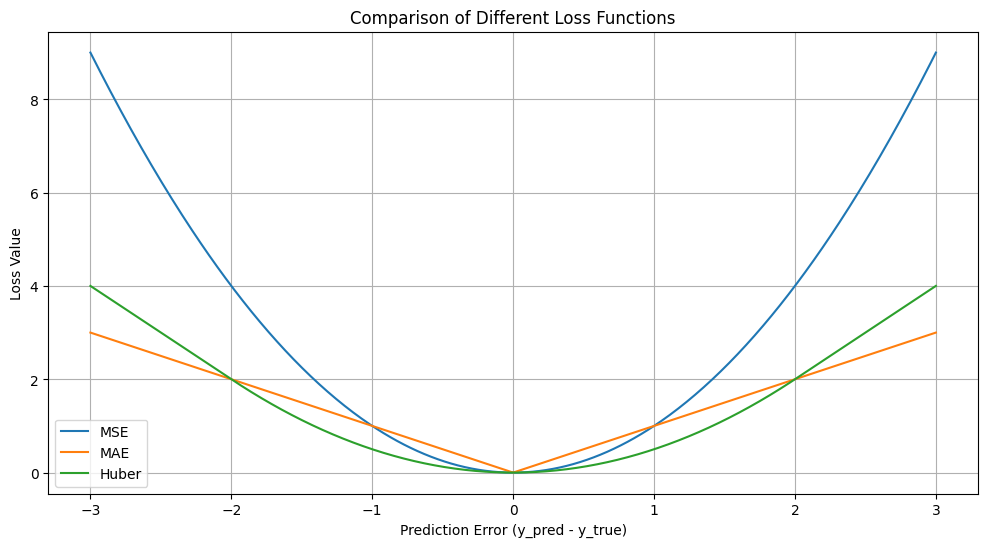

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt



# Crea una gamma di valori di errore tra y_true e y_pred
error_range = np.linspace(-3, 3, 500)
y_true = np.zeros_like(error_range)  # y_true è zero per semplicità
y_pred = error_range  # y_pred varia per simulare l'errore

# Calcolo delle perdite punto per punto
mse = tf.keras.losses.MeanSquaredError()
mse_loss = [mse(np.asarray([yt]), np.asarray([yp])).numpy() for yt, yp in zip(y_true, y_pred)]

mae = tf.keras.losses.MeanAbsoluteError()
mae_loss = [mae(np.asarray([yt]), np.asarray([yp])).numpy() for yt, yp in zip(y_true, y_pred)]

huber = tf.keras.losses.Huber(delta=2.0)
huber_loss = [huber(np.asarray([yt]), np.asarray([yp])).numpy() for yt, yp in zip(y_true, y_pred)]


# Creazione del grafico
plt.figure(figsize=(12, 6))
plt.plot(error_range, mse_loss, label="MSE")
plt.plot(error_range, mae_loss, label="MAE")
plt.plot(error_range, huber_loss, label="Huber")
plt.xlabel("Prediction Error (y_pred - y_true)")
plt.ylabel("Loss Value")
plt.title("Comparison of Different Loss Functions")
plt.legend()
plt.grid(True)
plt.show()

**Metrics**...
*   https://keras.io/api/metrics/


In [ ]:
from keras.metrics import Accuracy, Precision,Recall, F1Score, MeanAbsolutePercentageError
accuracy = Accuracy()
precision = Precision()
recall = Recall()
f1_score = F1Score()
mae_percentage = MeanAbsolutePercentageError()

#sklearn, scipy e altre, possono aiutare.

Esempio

In [ ]:
# Dati di esempio
y_true = tf.constant([[0.0], [1.0], [1.0], [0.0]], dtype=tf.float32)
y_pred = tf.constant([[0.0],[1.0], [1.0], [1.0]], dtype=tf.float32)


accuracy.update_state(y_true, y_pred)
precision.update_state(y_true, y_pred)
recall.update_state(y_true, y_pred)
f1_score.update_state(y_true, y_pred)

# Metrica di regressione
mae_percentage = MeanAbsolutePercentageError()
mae_percentage.update_state(y_true, y_pred)


# Ottieni i risultati delle metriche
accuracy_result = accuracy.result().numpy()
precision_result = precision.result().numpy()
recall_result = recall.result().numpy()
f1_score_result = f1_score.result().numpy()

print("Accuracy:", accuracy_result)
print("Precision:", precision_result) #riduce i falsi positivi
print("Recall:", recall_result) #riduce i falsi negativi
print("F1 Score:", f1_score_result)

Accuracy: 0.75
Precision: 0.6666667
Recall: 1.0
F1 Score: [0.79999995]


Tutto insieme

In [ ]:
import tensorflow as tf
import keras
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Input, Dense
from keras.models import Model
from keras.optimizers import AdamW,Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy



def load_and_preprocess_iris_dataset( test_split, valid_split, seed):
    # Carica il dataset Iris
    iris = load_iris()

    # Estrai le features e le etichette
    X = iris.data
    y = iris.target
    unique_values, _ = tf.unique(y)

    no_classes = tf.size(unique_values) # Trova il numero di classi uniche nel vettore delle etichette

    #Simple preprocessing
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    # y_encoded = tf.one_hot(y, depth=no_classes)

    # Suddivisione stratificata in set di addestramento e test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=valid_split, random_state=seed, stratify=y_train)

    y_train = tf.one_hot(y_train, depth=no_classes)
    y_val = tf.one_hot(y_val, depth=no_classes)
    y_test =  tf.one_hot(y_test, depth=no_classes)

    print("Dataset Info:")
    print(f"Class labels = {unique_values}")
    print(f"X_Training set shape = {tf.shape(X_train)}")
    print(f"X_Validation set shape = {tf.shape(X_val)}")
    print(f"X_Test set shape = {tf.shape(X_test)}")
    print(f"min features value {tf.reduce_min(X_train)}")
    print(f"max features value {tf.reduce_max(X_train)}")
    return (X_train,y_train),(X_val,y_val),(X_test,y_test)



##Hyperparamenters
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism() #influenza le prestazioni


data_input_shape=(4,)
data_output_shape=3
lr = 0.001
opt=Adam( learning_rate = lr)
# opt = AdamW(learning_rate=lr, weight_decay=0.01)
loss_fun = CategoricalCrossentropy()
accuracy = CategoricalAccuracy(name="acc")

num_epochs=30
batch_size=2

(X_train, y_train), (X_val, y_val), (X_test, y_test), = load_and_preprocess_iris_dataset(test_split=0.2, valid_split=0.125, seed=seed)


def my_first_neural_network(input_shape, output_shape ):
    # Input layer
    input_layer = Input(shape=input_shape)

    # Hidden layers with more neurons
    x = Dense(8, activation='relu')(input_layer)
    x = Dense(8, activation='relu')(x)

    # Output layer
    output_layer = Dense(output_shape, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    return model


model_b = my_first_neural_network(input_shape=data_input_shape, output_shape=data_output_shape)

model_b.compile(loss=loss_fun, optimizer=opt, metrics=[ accuracy ])
# model.summary()

# Addestramento del modello
history = model_b.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=num_epochs, batch_size=batch_size, shuffle=True)

Grazie ad history, tornato dal fit, possiamo monitorare e visualizzare il comportamento del modello durante il training e questo ci permette di fare il tuning degli iperparamentri.
Ad esempio, di seguito plottiamo i risultati...

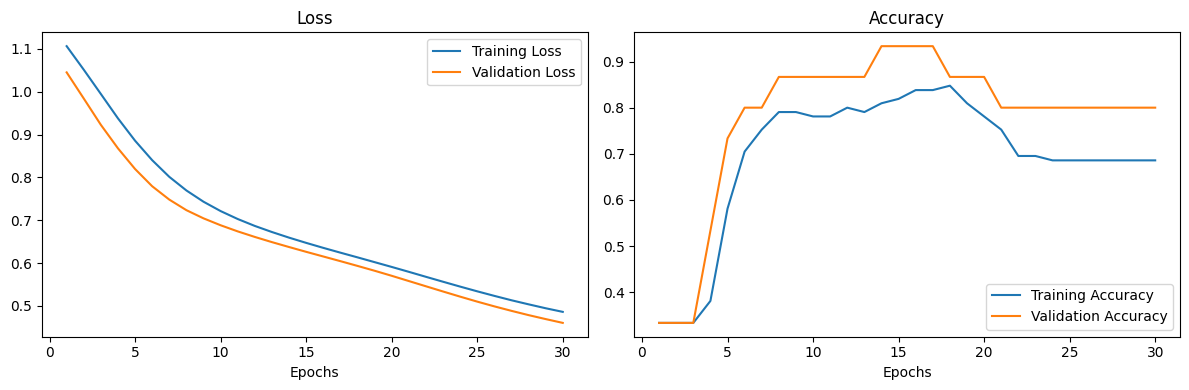

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, num_epochs):

    # Estrai la loss di training e validation
    training_loss = history.history['loss']
    validation_loss = history.history['val_loss']

    # Estrai le metriche di training e validation
    training_metrics = history.history['acc']
    validation_metrics = history.history['val_acc']

    # Crea un grafico
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, training_loss, label='Training Loss')
    plt.plot(epochs, validation_loss, label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, training_metrics, label='Training Accuracy')
    plt.plot(epochs, validation_metrics, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history, num_epochs)

Aumentiamo il livello di difficoltà e facciamoci una nostra categorical loss entropy



$$
L(y_{\text{true}}, y_{\text{pred}}) = - \frac{1}{N} \sum_{j=1}^{N} \sum_{i=1}^{C} y_{\text{true},ij} \cdot \log(y_{\text{pred},ij})
$$

dove:
- $( y_{\text{true}} $) : rappresenta le etichette reali in formato one-hot (un vettore di zeri con un solo uno per classe),
- $( y_{\text{pred}} $) : rappresenta le probabilità previste per ciascuna classe, dopo essere state scalate per evitare instabilità numeriche,
- $( C $) : è il numero delle classi.
- $( N $) è il numero totale delle osservazioni,

La cross-entropy misura la differenza tra le probabilità vere e quelle previste, penalizzando maggiormente le previsioni lontane dalle etichette reali e favorendo probabilità elevate per le classi corrette.


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.4931 - loss: 1.1036 - val_acc: 0.6667 - val_loss: 1.0580
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7296 - loss: 1.0436 - val_acc: 0.6667 - val_loss: 1.0124
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7296 - loss: 0.9948 - val_acc: 0.6667 - val_loss: 0.9700
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7440 - loss: 0.9486 - val_acc: 0.6667 - val_loss: 0.9243
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7440 - loss: 0.8995 - val_acc: 0.6667 - val_loss: 0.8716
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7440 - loss: 0.8442 - val_acc: 0.6667 - val_loss: 0.8157
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7440 - loss: 0.7887 - val_acc: 0.6667 - val_loss: 0.7598
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7440 - loss: 0.7319 - val_acc: 0.6667 - val_loss: 0.7052
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7440 - loss: 

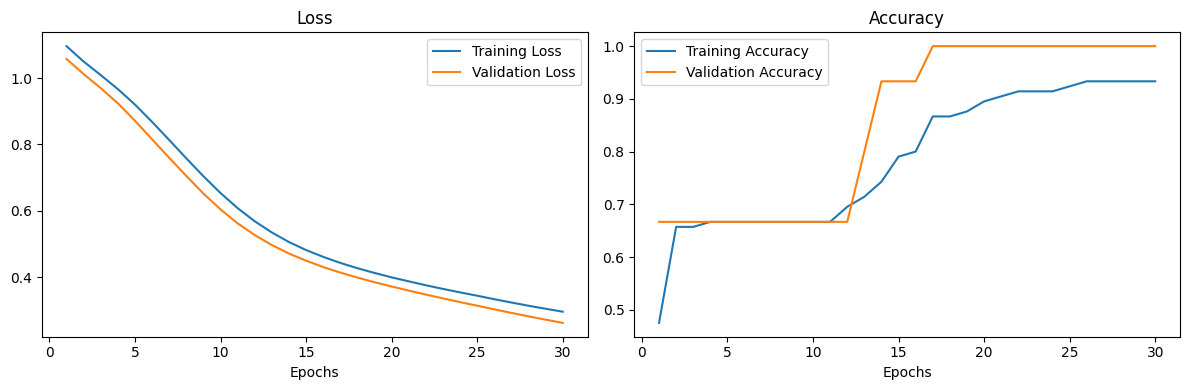

In [ ]:
# Definizione della funzione di perdita personalizzata
def my_categorical_crossentropy(y_true, y_pred):
    epsilon = 1e-8  # Aggiunto per evitare divisione per zero
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)  # Clip delle probabilità che devono essere comprese tra [0,1]
    losses = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return tf.reduce_mean(losses)

lr = 0.001
opt=Adam( learning_rate = lr)

model = my_first_neural_network(input_shape=data_input_shape, output_shape=data_output_shape)
model.compile(loss=my_categorical_crossentropy, optimizer=opt, metrics=[ accuracy ])

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=num_epochs, batch_size=batch_size)
plot_training_history(history, num_epochs)

##Evaluate

In [ ]:
(loss_value, acc_value) =  model.evaluate( X_val, y_val , batch_size=8 )

print(f"Val loss is {float(loss_value)}")
print(f"Val Accuracy is {float(acc_value)}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.2531 
Val loss is 0.2620413303375244
Val Accuracy is 1.0


In [ ]:
(loss_value, acc_value) =  model.evaluate( X_test, y_test , batch_size=8 )

print(f"Test loss is {float(loss_value)}")
print(f"Test Accuracy is {float(acc_value)}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9058 - loss: 0.2685 
Test loss is 0.2909121811389923
Test Accuracy is 0.8999999761581421


##Predict

In [ ]:
preds = model.predict( X_test, batch_size=8 )
print( np.round( preds , 3 ) )

results = np.argmax(preds, axis=1 )
print("\nPredicted Labels")
print( results )

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
[[0.975 0.025 0.001]
 [0.003 0.51  0.488]
 [0.134 0.703 0.162]
 [0.101 0.706 0.193]
 [0.981 0.019 0.   ]
 [0.008 0.677 0.316]
 [0.99  0.009 0.   ]
 [0.976 0.024 0.   ]
 [0.001 0.362 0.637]
 [0.017 0.713 0.27 ]
 [0.    0.168 0.832]
 [0.    0.298 0.702]
 [0.    0.232 0.767]
 [0.009 0.686 0.305]
 [0.983 0.017 0.   ]
 [0.981 0.019 0.   ]
 [0.993 0.007 0.   ]
 [0.031 0.698 0.271]
 [0.007 0.61  0.383]
 [0.003 0.538 0.459]
 [0.988 0.012 0.   ]
 [0.    0.228 0.771]
 [0.006 0.598 0.396]
 [0.001 0.353 0.646]
 [0.    0.212 0.788]
 [0.002 0.451 0.547]
 [0.008 0.639 0.353]
 [0.983 0.017 0.   ]
 [0.001 0.365 0.634]
 [0.983 0.017 0.   ]]

Predicted Labels
[0 1 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 2 2 2 1 0 2 0]


In [ ]:
preds = model( X_test)
results = np.argmax( preds, axis=1 )
print("Predicted Labels")
print( results )

Predicted Labels
[0 1 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 2 2 2 1 0 2 0]


Differenza fra i due modi di fare inferenza è che uno chiama la classe call, invece il predict è specificamente progettato per fare inferenza.

###Salvare e caricare i pesi di un modello

In [ ]:
model.save_weights("nome_file.weights.h5")
model.load_weights("nome_file.weights.h5")

Attenzione state salvando o caricando solo i pesi del modello non la sua struttura.

In [ ]:
model_b.save("model.keras")

loaded_model = tf.keras.models.load_model("model.keras")

Questo salva la sua struttura ma esistono altri metodi per farlo che non saranno discussi in questa lezione.

##Advanced Topics

###Callbacks

In [ ]:
from keras.callbacks import EarlyStopping

# Definisci la callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # Monitora la loss sulla metrica indicata
    min_delta=0.001,      # Variazione minima da considerare come miglioramento
    patience=10,          # Numero di epoche senza miglioramenti prima di fermare l'addestramento
    mode='auto',          # oppure prende "min","max", seleziona la direzione in automatico
    baseline=0.5,         # Baseline per il controllo,default è None.
    restore_best_weights=True,  # Ripristina i pesi migliori quando l'addestramento si ferma
    start_from_epoch=5    # Inizia il monitoraggio dall'epoca 5
)

lr = 0.001
opt=Adam( learning_rate = lr)
num_epochs=250
model = my_first_neural_network(input_shape=data_input_shape, output_shape=data_output_shape)
model.compile(loss=my_categorical_crossentropy, optimizer=opt, metrics=[ accuracy ])
# Addestramento del modello
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=num_epochs, batch_size=batch_size, callbacks=[early_stopping] )

Epoch 1/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5434 - loss: 1.0369 - val_acc: 0.3333 - val_loss: 1.0608
Epoch 2/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.3949 - loss: 1.0129 - val_acc: 0.3333 - val_loss: 1.0345
Epoch 3/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.3949 - loss: 0.9926 - val_acc: 0.3333 - val_loss: 1.0073
Epoch 4/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4168 - loss: 0.9702 - val_acc: 0.3333 - val_loss: 0.9786
Epoch 5/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4354 - loss: 0.9476 - val_acc: 0.3333 - val_loss: 0.9533
Epoch 6/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.5530 - loss: 0.9241 - val_acc: 0.4667 - val_loss: 0.9263
Epoch 7/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6510 - loss: 0.8964 - val_acc: 0.6667 - val_loss: 0.8952
Epoch 8/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7181 - loss: 0.8645 - val_acc: 0.6667 - val_loss: 0.8597
Epoch 9/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7346

## Esercizio di classificazione con MLPClassifier

[MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) è una classe della libreria **Scikit Learn** per l'addestramento di una rete neurale multistrato perceptron (MLP) per attività di classificazione. Una MLP è un tipo di rete neurale feedforward costituita da più strati di neuroni, ciascuno dei quali è connesso al successivo. La classe MLPClassifier offre diverse opzioni per definire l'architettura di rete, addestrare il modello e valutarne le prestazioni. Può essere utilizzata per un'ampia gamma di attività di classificazione, tra cui la classificazione di immagini, la classificazione di testo e la classificazione di serie temporali.

Importiamo il MNIST dataset, costituito da immagini di cifre scritte a mano

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

Carica i dati usando la funzione di scikit learn fetch_openml

In [ ]:
# Load data from https://www.openml.org/d/554
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mnist = fetch_openml(name='mnist_784',parser='pandas',version=1, cache=False)

In [ ]:
mnist.data.shape

(70000, 784)

Ci sono 70.000 immagini e ogni immagine ha 784 feature (ogni immagine è di 28 x 28 pixel e ogni pixel rappresenta una feature di un'immagine)

Ogni immagine del dataset MNIST è codificata in un vettore a 784 dimensioni, che rappresenta un'immagine di 28 x 28 pixel. Ogni pixel ha un valore compreso tra 0 e 255, che rappresenta l'intensità del pixel, da 0 (bianco) a 255 (nero), corrispondente al valore di grigio di un pixel.

Il metodo featch_mldata sopra descritto per caricare MNIST restituisce dati e target come uint8, che convertiamo rispettivamente in float32 e int64.

In [ ]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')
X.head(1)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


I dati MNIST sono già suddivisi in un set di training (le prime 60.000 immagini) e un set di test (le ultime 10.000 immagini). Inoltre, il set di training è già stato riorganizzato per noi!

Possiamo quindi usare semplicemente lo slicing delle liste in Python per generare i nostri set di dati dall'intero set di immagini.


In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
X_train.shape, y_train.shape

((60000, 784), (60000,))

In [ ]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].values.reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

Stampa una selezione di immagini di train e le loro etichette

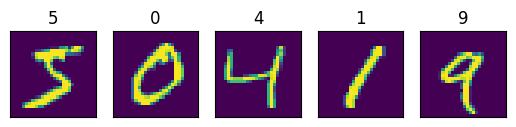

In [ ]:
plot_example(X_train, y_train)

I dati di train sono bilanciati?

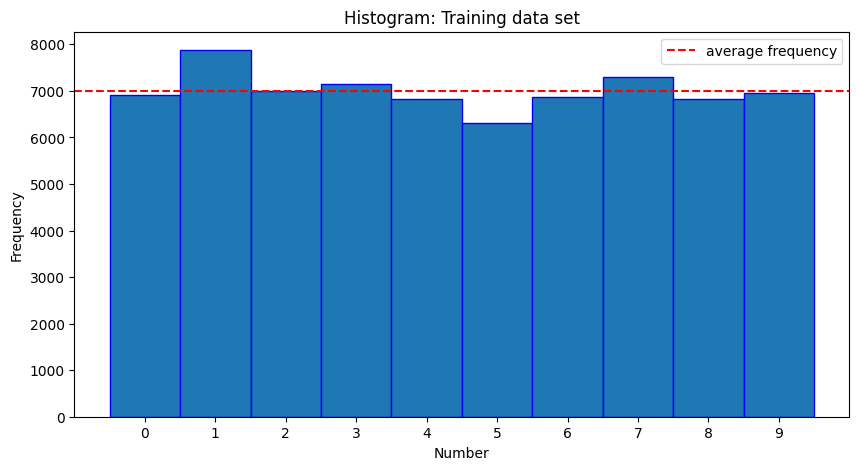

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
ax.hist(y,bins=[0,1,2,3,4,5,6,7,8,9,10], edgecolor="b", histtype="bar",align='left')
ax.set_title('Histogram: Training data set')
ax.set(xlabel='Number', ylabel='Frequency')
ax.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9] );
ax.axhline(y=(y.size/10), label="average frequency",linestyle='dashed', color='r')
ax.legend()

Possiamo vedere che il numero di esempi per ogni numero da rilevare non è distribuito uniformemente. Ci sono più esempi 1, 3 e 7 nel set di dati.

## Costruiamo una rete neurale usando MLPClassifier

Costruiamo una rete neurale semplice e completamente connessa con tre hidden layer con i seguenti parametri:

Modello che utilizza un MLPClassifier (Multi layer Perceptron Classifier)
Costruiamo il modello con 3 strati nascosti come segue:

* strato nascosto = 256 neuroni
* strato nascosto = 128 neuroni
* strato nascosto = 32 neuroni

Usiamo anche questi parametri:

* solver ='adam'
* learning_rate_init= 0.001
* tol=1e-2
* max_iter= 500
* verbose = True
* random_state=1
È possibile utilizzare i valori predefiniti per i restanti parametri.

Il layer di input ha 784 dimensioni (28x28) e il layer di output 10 neuroni, che rappresentano le cifre da 0 a 9. MLPClassifier implementa un algoritmo di percettroni multistrato (MLP) che si addestra utilizzando la backpropagation. MLP si addestra su due array: array X di dimensione (n_samples, n_features), che contiene i campioni di addestramento rappresentati come vettori di feature in virgola mobile; e array y di dimensione (n_samples,), che contiene i valori target (etichette di classe) per i campioni di addestramento.

In [ ]:
from sklearn.neural_network import MLPClassifier
#TO-DO Instantiate the model and name it as below
mlp_mnist_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 32),
    solver='adam',
    learning_rate_init=0.001,
    tol=1e-2,
    max_iter=500,
    verbose=True,
    random_state=1)

In [ ]:
mlp_mnist_model.fit(X_train, y_train)

Iteration 1, loss = 1.22507001
Iteration 2, loss = 0.37515061
Iteration 3, loss = 0.24975711
Iteration 4, loss = 0.18225896
Iteration 5, loss = 0.15311519
Iteration 6, loss = 0.12552480
Iteration 7, loss = 0.10271610
Iteration 8, loss = 0.09168221
Iteration 9, loss = 0.08015661
Iteration 10, loss = 0.06990729
Iteration 11, loss = 0.07124171
Iteration 12, loss = 0.07380803
Iteration 13, loss = 0.05884140
Iteration 14, loss = 0.05719959
Iteration 15, loss = 0.04842121
Iteration 16, loss = 0.06105281
Iteration 17, loss = 0.04765782
Iteration 18, loss = 0.04460270
Iteration 19, loss = 0.03719462
Iteration 20, loss = 0.04021621
Iteration 21, loss = 0.03711709
Iteration 22, loss = 0.03958275
Iteration 23, loss = 0.02585702
Iteration 24, loss = 0.03434442
Iteration 25, loss = 0.02784102
Iteration 26, loss = 0.03514003
Iteration 27, loss = 0.03146331
Iteration 28, loss = 0.02509959
Iteration 29, loss = 0.02288407
Iteration 30, loss = 0.02515987
Iteration 31, loss = 0.02021748
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(256, 128, 32), max_iter=500, random_state=1,
              tol=0.01, verbose=True)

In [ ]:
mlp_mnist_model.out_activation_


'softmax'

In [ ]:
mlp_mnist_model.n_layers_


5

In [ ]:

mlp_mnist_model.n_outputs_


10

In [ ]:
mlp_mnist_model.n_iter_

34

In [ ]:
mlp_mnist_model.score(X_test, y_test)
0.9802
from sklearn.metrics import accuracy_score
y_pred = mlp_mnist_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9753

Una precisione di circa il 98% per una rete con solo due livelli nascosti non è poi così male.

Diamo un'occhiata ad alcune previsioni andate male:

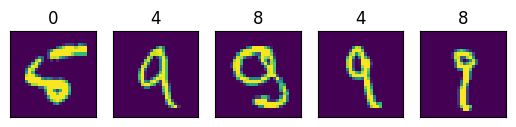

In [ ]:
error_mask = y_pred != y_test
plot_example(X_test[error_mask], y_pred[error_mask])

In [ ]:
loss_values = mlp_mnist_model.loss_curve_
print('loss values are {}'.format(loss_values))

loss values are [np.float64(1.2250700053982178), np.float64(0.3751506062619353), np.float64(0.24975711350571808), np.float64(0.1822589630710274), np.float64(0.15311519235236737), np.float64(0.12552480039416025), np.float64(0.10271610379056503), np.float64(0.09168221292378821), np.float64(0.08015660683332111), np.float64(0.0699072885194114), np.float64(0.07124170514150517), np.float64(0.07380803113370996), np.float64(0.058841402937570814), np.float64(0.05719958825155627), np.float64(0.04842121216420923), np.float64(0.061052808538626456), np.float64(0.04765782148041835), np.float64(0.044602701193481954), np.float64(0.03719462043802802), np.float64(0.04021621352424161), np.float64(0.03711709420100055), np.float64(0.03958274855251267), np.float64(0.025857015363102327), np.float64(0.03434441673029718), np.float64(0.02784101725069895), np.float64(0.035140025268247534), np.float64(0.03146330844112043), np.float64(0.02509958702130754), np.float64(0.022884073871278107), np.float64(0.02515987165

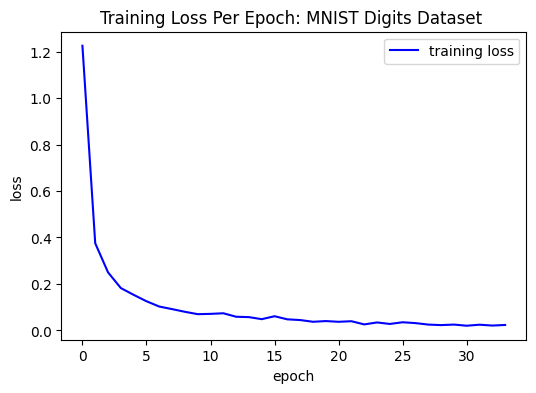

In [ ]:
# TO-DO Plot the loss_values (Label each axis, put in a legend and put a title on plot.)
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
plt.plot(loss_values, color="blue", label = 'training loss')
plt.xlabel('epoch')
plt.ylabel('loss');
#legend
plt.legend(loc='upper right')
#title
plt.title('Training Loss Per Epoch: MNIST Digits Dataset ')
#show plot
plt.show()

**Classification report**

In [ ]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.97      0.97      0.97       892
           6       0.99      0.97      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



**Matrice di confusione**


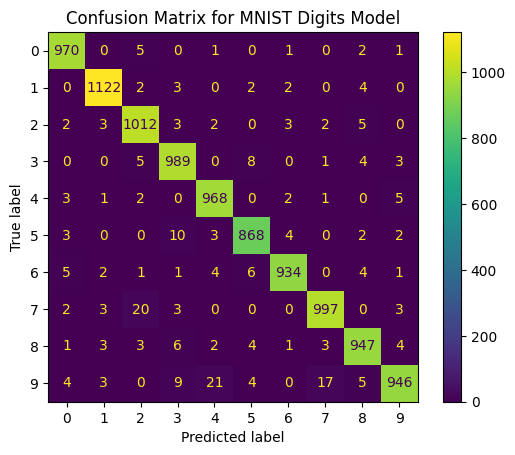

In [ ]:
#TO-DO: print a pretty confusion matrix (see previous notebooks)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix for the MNIST model
cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))

# Create a ConfusionMatrixDisplay object with the correct labels (0-9)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))

# Plot the confusion matrix
disp.plot()
plt.title('Confusion Matrix for MNIST Digits Model')
plt.show()

La cifra più difficile da classificare è stata la cifra 5. Questo perché il modello ha cercato di classificarla come diverse altre cifre. Ad esempio, il modello ha provato a classificare la cifra 5 come cifra 3 dieci volte. Inoltre, ha tentato di classificare la cifra 5 come altre cifre anche in diverse altre occasioni.

Proviamo a cambiare con 'sgd' ma qua si ha una diminuzione delle performance

In [ ]:
mlp_mnist_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 32),
    solver='sgd',
    learning_rate_init=0.001,
    tol=1e-2,
    max_iter=500,
    verbose=True,
    random_state=1)

mlp_mnist_model.fit(X_train, y_train)

mlp_mnist_model.score(X_test, y_test)

Iteration 1, loss = 2.14322972
Iteration 2, loss = 1.08021272
Iteration 3, loss = 0.67271528
Iteration 4, loss = 0.54929975
Iteration 5, loss = 0.42122504
Iteration 6, loss = 0.33388987
Iteration 7, loss = 0.28800665
Iteration 8, loss = 0.26323469
Iteration 9, loss = 0.23941568
Iteration 10, loss = 0.22036412
Iteration 11, loss = 0.21004745
Iteration 12, loss = 0.19822195
Iteration 13, loss = 0.18586475
Iteration 14, loss = 0.17917755
Iteration 15, loss = 0.17502151
Iteration 16, loss = 0.16208232
Iteration 17, loss = 0.15585111
Iteration 18, loss = 0.14838629
Iteration 19, loss = 0.14222501
Iteration 20, loss = 0.13600306
Iteration 21, loss = 0.12709478
Iteration 22, loss = 0.12414167
Iteration 23, loss = 0.11605178
Iteration 24, loss = 0.11354060
Iteration 25, loss = 0.10926202
Iteration 26, loss = 0.10381058
Iteration 27, loss = 0.10131245
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


0.9494

Fornisci al modello una singola immagine dal set di test da classificare e fai in modo che il modello restituisca le probabilità di appartenenza alla classe e le stampi per questa classificazione di immagini singole. Nota: devi ridimensionare l'immagine a 28 x 28 prima di provare a visualizzarla! Inoltre, puoi utilizzare l'ultimo modello addestrato se la tua accuratezza è > 95%.

In [ ]:

#TO DO - Class Membership Probabilities

# Select a single image from the test set
single_image = X_test[54:55]

# Predict class probabilities for the single image
probabilities = mlp_mnist_model.predict_proba(single_image)
print('Class membership probabilities are {}'.format(probabilities))
print('Sum of the probabilities are {}'.format(np.sum(probabilities)))

Class membership probabilities are [[9.59049071e-31 4.74958753e-11 9.81917103e-10 9.50437865e-19
  1.03112354e-04 1.35627710e-17 9.99896884e-01 9.02043171e-17
  2.64410733e-08 6.01790143e-15]]
Sum of the probabilities are 1.0


 La classe predetta è quella con la probabilità più alta, ovvero 6 (indice 6, con ~99.99% di confidenza). Le altre probabilità sono trascurabili, il che indica che il modello è molto sicuro della sua previsione.

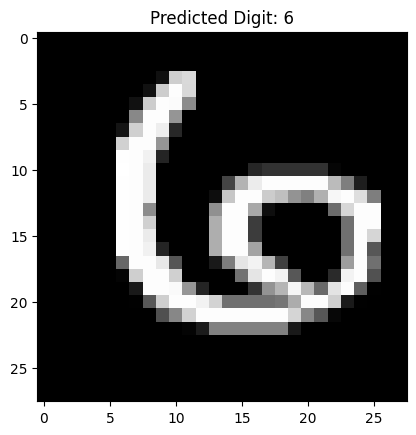

In [ ]:
#TO DO - Plot Image
single_image_np = single_image.to_numpy().reshape(28,28)

# Display the image
plt.imshow(single_image_np, cmap='gray')
plt.title(f'Predicted Digit: {np.argmax(probabilities)}')
plt.show()

In [ ]:
# TO DO - Print the value from y_test to compare with the image
actual_label = y_test.iloc[54]

print(f"Value from y_test: {actual_label}")

Value from y_test: 6


# Transfer Learning

Il transfer learning è una tecnica di apprendimento automatico in cui un modello addestrato su un'attività viene riutilizzato come base per una seconda attività. Questo approccio è utile quando la seconda attività è correlata alla prima o quando i dati per la seconda attività sono limitati.

Utilizzando le feature apprese dal compito iniziale, il modello può adattarsi in modo più efficiente al nuovo compito, accelerando l'apprendimento e migliorando le prestazioni. Il transfer learning riduce anche il rischio di overfitting, poiché il modello incorpora già feature generalizzabili utili per il secondo compito

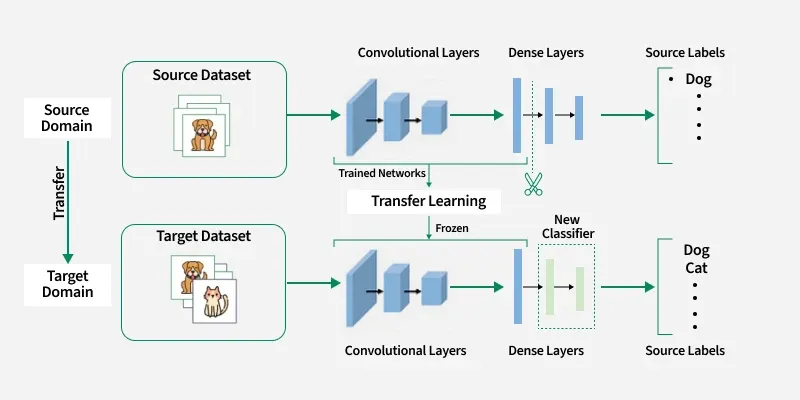

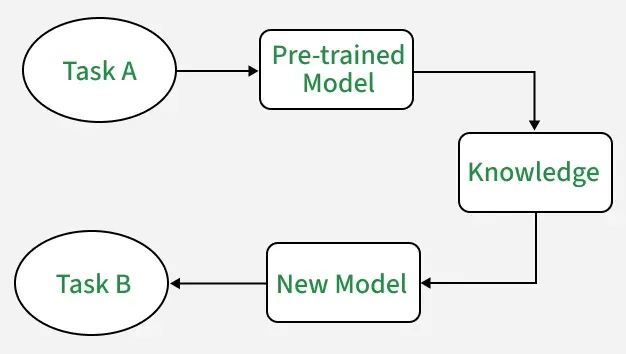

## Livelli congelati vs livelli addestrabili

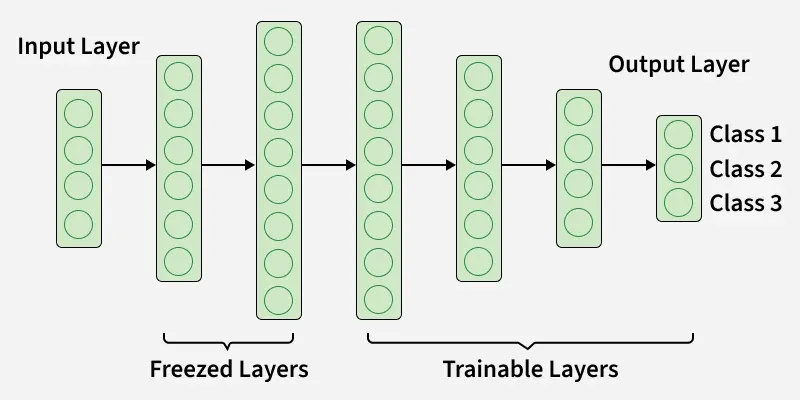

**Blobs Multi-Class Classification Problem with Transfer Learning**
Per casa guarda questo tutorial: https://machinelearningmastery.com/how-to-improve-performance-with-transfer-learning-for-deep-learning-neural-networks/

## Esercizio: Transfer Learning con MobileNetV2 per la classificazione MNIST
Esploreremo l'apprendimento tramite transfer learning perfezionando un modello [MobileNetV2](
  https://www.geeksforgeeks.org/computer-vision/mobilenet-v2-architecture-in-computer-vision/
) pre-addestrato su ImageNet per la classificazione delle cifre MNIST.







**Architettura MobileNetV2**
* Conv Iniziale (Standard):Un singolo strato Conv2D per l'estrazione iniziale (es. 224x224 -> 112x112).
* Sequenza di Blocchi Residui Invertiti (x17):Questo è il "cuore" della rete.
  1. Expansion (Espansione): Conv 1x1 per aumentare i canali (es. 32 $\rightarrow$ 192).
  2. Depthwise Conv: Conv 3x3 (molto efficiente) per filtrare i dati espansi.
  3. Projection (Proiezione): Conv 1x1 (lineare) per ridurre di nuovo i canali (es. 192 $\rightarrow$24)
* Downsampling: Alcuni blocchi usano stride=2 per ridurre la dimensione (es. 56x56 -> 28x28).
* Conv Finale (Standard):Un ultimo Conv 1x1 per preparare le features alla classificazione.
* Global Average Pooling:Collassa l'intera mappa delle features (es. 7x7x1280) in un singolo vettore (1x1x1280).Sostituisce gli strati Flatten pesanti.
* Strato Classificatore (Dense):Un singolo strato Fully Connected (Dense) per produrre l'output finale (es. 1000 classi).

**Preparazione del set di dati**
Iniziamo caricando il dataset MNIST . Poiché MobileNetV2 è pre-addestrato su immagini RGB a tre canali di dimensioni 224x224, apportiamo alcune modifiche per adattarlo alla forma di input prevista:

* Rimodellare le immagini da scala di grigi (28x28, 1 canale) a RGB (28x28, 3 canali).
* Ridimensioniamo le immagini a 32x32 pixel, allineandole alla configurazione del nostro modello.
* Normalizzare i valori dei pixel in modo che siano compresi tra 0 e 1 dividendo per 255.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# carica MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# replica il canale grigio 3 volte e normalizza in float32
train_images = np.stack([train_images] * 3, axis=-1).astype('float32') / 255.0   # shape (60000, 28, 28, 3)
test_images  = np.stack([test_images] * 3, axis=-1).astype('float32')  / 255.0

# ridimensiona a 32x32 con tf.image.resize (ritorna un tensor)
train_images = tf.image.resize(train_images, [32, 32]).numpy()   # ora (60000, 32, 32, 3)
test_images  = tf.image.resize(test_images,  [32, 32]).numpy()

# one-hot encode delle label
train_labels = to_categorical(train_labels, 10)
test_labels  = to_categorical(test_labels, 10)

print(train_images.shape, train_labels.shape)  # (60000, 32, 32, 3) (60000, 10)
print(test_images.shape, test_labels.shape)    # (10000, 32, 32, 3) (10000, 10)

(60000, 32, 32, 3) (60000, 10)
(10000, 32, 32, 3) (10000, 10)


**Costruzione del modello**
Carichiamo MobileNetV2 con pesi pre-addestrati da ImageNet, escludendo gli strati superiori completamente connessi, per **personalizzarli per la nostra attività di classificazione a 10 classi**:

 * Congela il modello di base per conservare le funzionalità apprese ed evitare l'overfitting.
* Aggiungere un livello di pooling medio globale per ridurre la complessità del modello.
* Aggiungere uno strato denso con attivazione softmax per le classi di output.

> In Keras, puoi creare un'istanza per un modello preaddestrato dalla raccolta tf.keras.applications.*. MobileNet V2, ad esempio, è un'ottima architettura convoluzionale che rimane di dimensioni ragionevoli. Se selezioni `include_top=False`, ottieni il modello preaddestrato senza il suo strato softmax finale, in modo da poter aggiungere il tuo.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

/tmp/ipython-input-3104373990.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Il modello è compilato utilizzando la categorical cross entropy come funzione di perdita e l'accuratezza come metrica di valutazione.
Utilizzando l'ottimizzatore Adam, addestriamo il modello sui dati di training MNIST per dieci epoche.

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.4500 - loss: 1.8232 - val_accuracy: 0.6035 - val_loss: 1.2969
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.6040 - loss: 1.2613 - val_accuracy: 0.6352 - val_loss: 1.1397
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.6399 - loss: 1.1295 - val_accuracy: 0.6546 - val_loss: 1.0727
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.6502 - loss: 1.0729 - val_accuracy: 0.6607 - val_loss: 1.0362
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.6527 - loss: 1.0479 - val_accuracy: 0.6649 - val_loss: 1.0151
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/step - accuracy: 0.6594 - loss: 1.0255 - val_accuracy: 0.6674 - val_loss: 1.0001
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.6632 - loss: 1.0086 - val_accuracy: 0.6688 - val_loss: 0.9895
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.6641 -

Dopo l'addestramento iniziale, sblocchiamo gli ultimi strati del modello base per eseguire un fine tuning preciso. Ciò consente al modello di adattare le caratteristiche di alto livello ai dati MNIST, mantenendo al contempo le sue conoscenze fondamentali.

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 199s 122ms/step - accuracy: 0.2293 - loss: 10.7849 - val_accuracy: 0.1373 - val_loss: 8.9473
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 182s 121ms/step - accuracy: 0.4754 - loss: 2.3958 - val_accuracy: 0.2461 - val_loss: 2.3719
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 184s 109ms/step - accuracy: 0.6087 - loss: 1.4737 - val_accuracy: 0.6507 - val_loss: 1.1123
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 201s 109ms/step - accuracy: 0.6990 - loss: 1.0724 - val_accuracy: 0.8127 - val_loss: 0.6721
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 163s 108ms/step - accuracy: 0.7593 - loss: 0.8551 - val_accuracy: 0.8492 - val_loss: 0.5250


Una volta addestrato e perfezionato il modello, lo valutiamo sul set di test, misurandone la perdita e l'accuratezza. Questa fase valuta l'adattamento del modello di apprendimento per trasferimento al dataset MNIST e ne dimostra l'efficacia nella classificazione delle cifre.

In [ ]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8289 - loss: 0.5824
Test loss: 0.5463611483573914
Test accuracy: 0.8414000272750854


Visualizziamo meglio le prestazioni con una matrice di accuratezza

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step


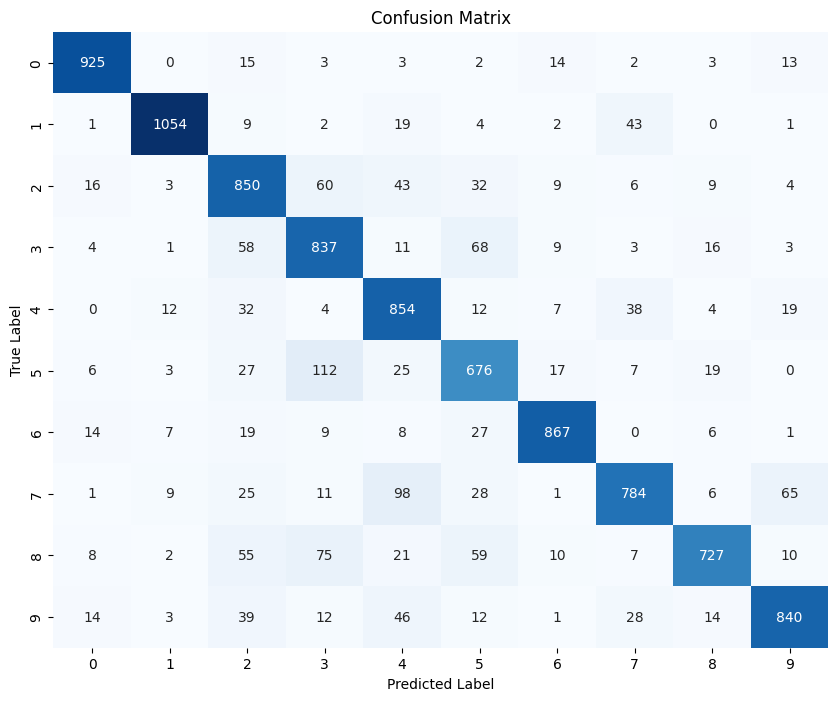

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Infine selezioniamo alcune immagini di prova per visualizzare le previsioni del modello rispetto alle loro etichette reali.

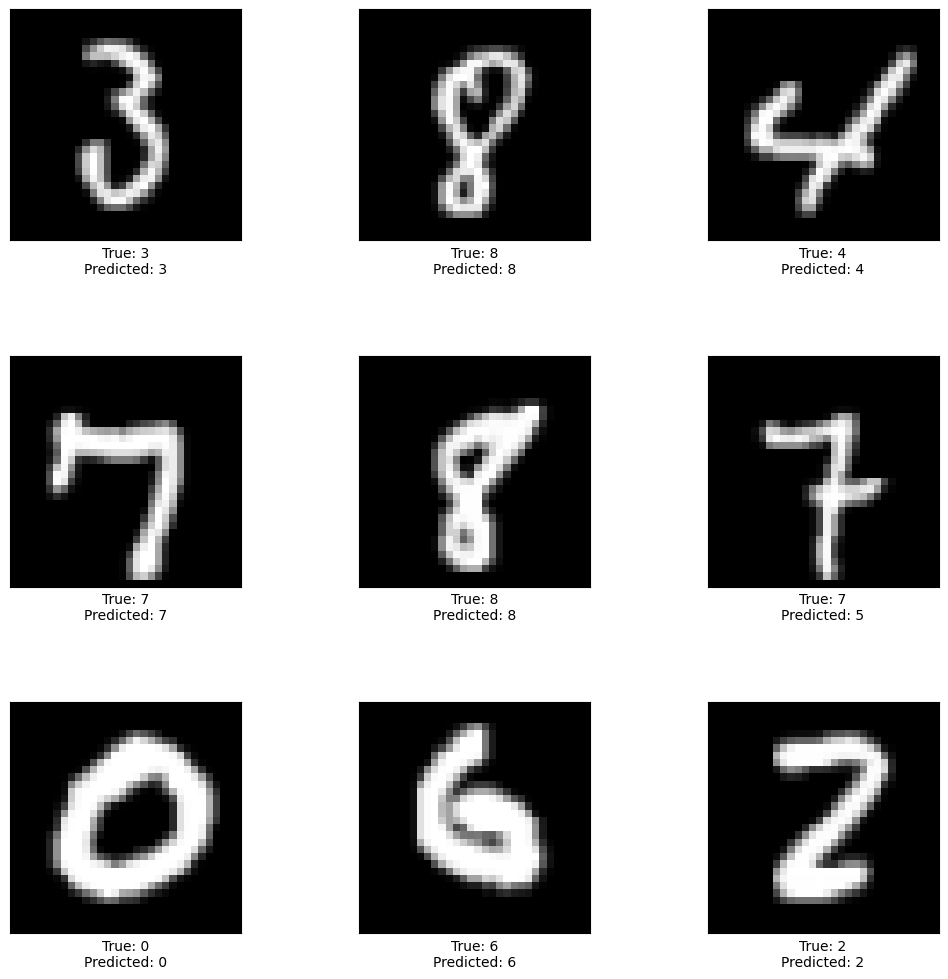

In [ ]:
def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)